In [6]:
import pandas as pd
df = pd.read_csv('csgo_players.csv')
df.head()

,player_id,nickname,real_name,age,country,current_team,teams,total_kills,total_deaths,headshot_percentage,...,3_kill_rounds,4_kill_rounds,5_kill_rounds,rifle_kills,sniper_kills,smg_kills,pistol_kills,grenade_kills,other_kills,rating
0,11893,ZywOo,Mathieu Herbaut,21,France,Vitality,"Vitality, aAa",22622,16458,41.2%,...,1474,369,71,8261,8552,1290,4262,260,49,1.32
1,7998,s1mple,Aleksandr Kostyliev,24,Ukraine,Natus Vincere,Natus Vincere,35512,26413,41.3%,...,2262,504,64,14717,13451,901,6057,199,254,1.25
2,16920,sh1ro,Dmitry Sokolov,21,Russia,Cloud9,"Gambit Youngsters, Gambit",18091,12492,27.8%,...,1075,221,30,3791,10580,550,3008,175,70,1.26
3,20113,deko,Denis Zhukov,21,Russia,1WIN,1WIN,8738,6397,36.7%,...,518,112,8,2664,4348,181,1459,86,40,1.23
4,18835,saffee,Rafael Costa,27,Brazil,FURIA,"FURIA, paiN",8482,6517,30.9%,...,524,114,14,2545,4412,264,1209,52,28,1.22


## 1. Visão geral

811 jogadores × 41 colunas. Cada linha é um jogador profissional de CS:GO com estatísticas de carreira agregadas (kills, deaths, rating HLTV, distribuição de armas, opening duels etc.).

In [7]:
print(f'Linhas x Colunas: {df.shape}')
print(f'Memória: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('\nTipos de dados:')
df.dtypes.value_counts()

Linhas x Colunas: (811, 41)
Memória: 668.9 KB

Tipos de dados:


int64      21
float64    11
str         9
Name: count, dtype: int64

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 811 entries, 0 to 810
Data columns (total 41 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   player_id                          811 non-null    int64  
 1   nickname                           811 non-null    str    
 2   real_name                          811 non-null    str    
 3   age                                811 non-null    int64  
 4   country                            811 non-null    str    
 5   current_team                       514 non-null    str    
 6   teams                              811 non-null    str    
 7   total_kills                        811 non-null    int64  
 8   total_deaths                       811 non-null    int64  
 9   headshot_percentage                811 non-null    str    
 10  damage_per_round                   811 non-null    float64
 11  grenade_dmg_per_round              811 non-null    float64
 12  maps_

## 2. Qualidade dos dados

Pontos identificados na inspeção inicial:

- **`current_team`** tem 297 valores nulos (jogadores aposentados / sem time atual).
- **`headshot_percentage`**, **`team_win_percent_after_first_kill`** e **`first_kill_in_won_rounds`** chegam como string com `%` — precisam virar `float`.
- **`kill_to_death_diff`** veio quebrado do scraping: todas as 811 linhas têm o texto literal `"K - D diff."`. O valor real pode ser recalculado como `total_kills - total_deaths`.
- Demais colunas numéricas já vêm corretas (`int64` / `float64`).

In [9]:
missing = df.isna().sum()
missing = missing[missing > 0].to_frame('nulos')
missing['%'] = (missing['nulos'] / len(df) * 100).round(2)
missing

,nulos,%
current_team,297,36.62


In [10]:
print('kill_to_death_diff (suposto numérico) — valores únicos:')
print(df['kill_to_death_diff'].unique())

print('\nAmostra das colunas com "%":')
df[['headshot_percentage', 'team_win_percent_after_first_kill', 'first_kill_in_won_rounds']].head()

kill_to_death_diff (suposto numérico) — valores únicos:
<StringArray>
['K - D diff.']
Length: 1, dtype: str

Amostra das colunas com "%":


,headshot_percentage,team_win_percent_after_first_kill,first_kill_in_won_rounds
0,41.2%,73.1%,21.4%
1,41.3%,75.2%,20.8%
2,27.8%,77.0%,16.2%
3,36.7%,76.4%,16.7%
4,30.9%,76.1%,17.3%


## 3. Limpeza

- Converte as 3 colunas de porcentagem para `float` (0–100).
- Substitui `kill_to_death_diff` pelo valor real (`total_kills - total_deaths`).
- Cria `has_team` para distinguir jogadores ativos vs. sem time.

In [11]:
pct_cols = ['headshot_percentage', 'team_win_percent_after_first_kill', 'first_kill_in_won_rounds']
for c in pct_cols:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].astype(str).str.rstrip('%').astype(float)

df['kill_to_death_diff'] = df['total_kills'] - df['total_deaths']
df['has_team'] = df['current_team'].notna()

df[pct_cols + ['kill_to_death_diff', 'has_team']].head()

,headshot_percentage,team_win_percent_after_first_kill,first_kill_in_won_rounds,kill_to_death_diff,has_team
0,41.2,73.1,21.4,6164,True
1,41.3,75.2,20.8,9099,True
2,27.8,77.0,16.2,5599,True
3,36.7,76.4,16.7,2341,True
4,30.9,76.1,17.3,1965,True


## 4. Estatísticas descritivas (numéricas)

In [12]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
player_id,811.0,10025.052,4670.266,7.00,7853.50,9766.00,13143.000,20113.00
age,811.0,25.852,3.697,17.00,23.00,26.00,28.000,36.00
total_kills,811.0,15324.868,7616.041,5530.00,9222.00,13308.00,19404.000,40979.00
total_deaths,811.0,14734.414,7092.811,6166.00,9116.00,12900.00,18366.500,38534.00
headshot_percentage,811.0,45.454,8.437,23.60,40.35,47.30,51.500,68.10
damage_per_round,811.0,75.111,4.121,59.70,72.40,74.90,77.750,91.70
grenade_dmg_per_round,811.0,4.073,1.188,1.40,3.20,3.90,4.800,9.20
maps_played,811.0,843.348,406.504,379.00,509.00,738.00,1073.000,2219.00
rounds_played,811.0,22172.041,10719.502,9815.00,13459.00,19559.00,28229.000,58263.00
kills_per_death,811.0,1.035,0.092,0.74,0.98,1.03,1.095,1.45


## 5. Análise categórica

Países e times com mais jogadores no dataset.

In [13]:
print(f"Países distintos: {df['country'].nunique()}")
print(f"Times atuais distintos: {df['current_team'].nunique()}")
print(f"Jogadores com time atual: {df['has_team'].sum()} | sem time: {(~df['has_team']).sum()}")

print('\nTop 15 países:')
print(df['country'].value_counts().head(15))

print('\nTop 15 times atuais:')
print(df['current_team'].value_counts().head(15))

Países distintos: 53
Times atuais distintos: 190
Jogadores com time atual: 514 | sem time: 297

Top 15 países:
country
United States    82
Denmark          73
Russia           67
Brazil           61
Sweden           53
Poland           50
Australia        44
China            28
France           26
Finland          26
Canada           25
Germany          25
Ukraine          24
Bulgaria         23
Kazakhstan       16
Name: count, dtype: int64

Top 15 times atuais:
current_team
MOUZ             8
HAVU             8
Natus Vincere    7
OG               7
NIP              7
Liquid           7
Complexity       7
Heroic           7
TYLOO            6
00NATION         6
Entropiq         6
FaZe             6
Apeks            6
fnatic           6
ENCE             6
Name: count, dtype: int64


## 6. Top jogadores por `rating`

`rating` é a métrica-síntese da HLTV (acima de 1.0 = acima da média).

In [14]:
df.nlargest(15, 'rating')[
    ['nickname', 'country', 'current_team', 'age', 'rating',
     'kills_per_round', 'headshot_percentage', 'maps_played']
]

,nickname,country,current_team,age,rating,kills_per_round,headshot_percentage,maps_played
0,ZywOo,France,Vitality,21,1.32,0.84,41.2,1020
2,sh1ro,Russia,Cloud9,21,1.26,0.77,27.8,884
1,s1mple,Ukraine,Natus Vincere,24,1.25,0.86,41.3,1571
3,deko,Russia,1WIN,21,1.23,0.80,36.7,404
4,saffee,Brazil,FURIA,27,1.22,0.79,30.9,404
15,blameF,Denmark,Astralis,25,1.22,0.76,39.2,884
6,degster,Russia,OG,21,1.21,0.78,34.7,686
10,SENSEi,Ukraine,Iron Branch,23,1.21,0.75,31.3,474
22,Texta,Australia,NaN,21,1.21,0.80,40.3,625
7,smooya,United Kingdom,NaN,22,1.20,0.79,27.8,888


## 7. Setup visual

Nesta etapa vamos visualizar distribuições, relações com `rating`, diferenças por país/time e perfis de armas.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

rating_color = '#2f80ed'
highlight_color = '#f2994a'
neutral_color = '#6c757d'

## 8. Distribuições principais

Vamos começar com histogramas das métricas centrais para entender escala, concentração e caudas.

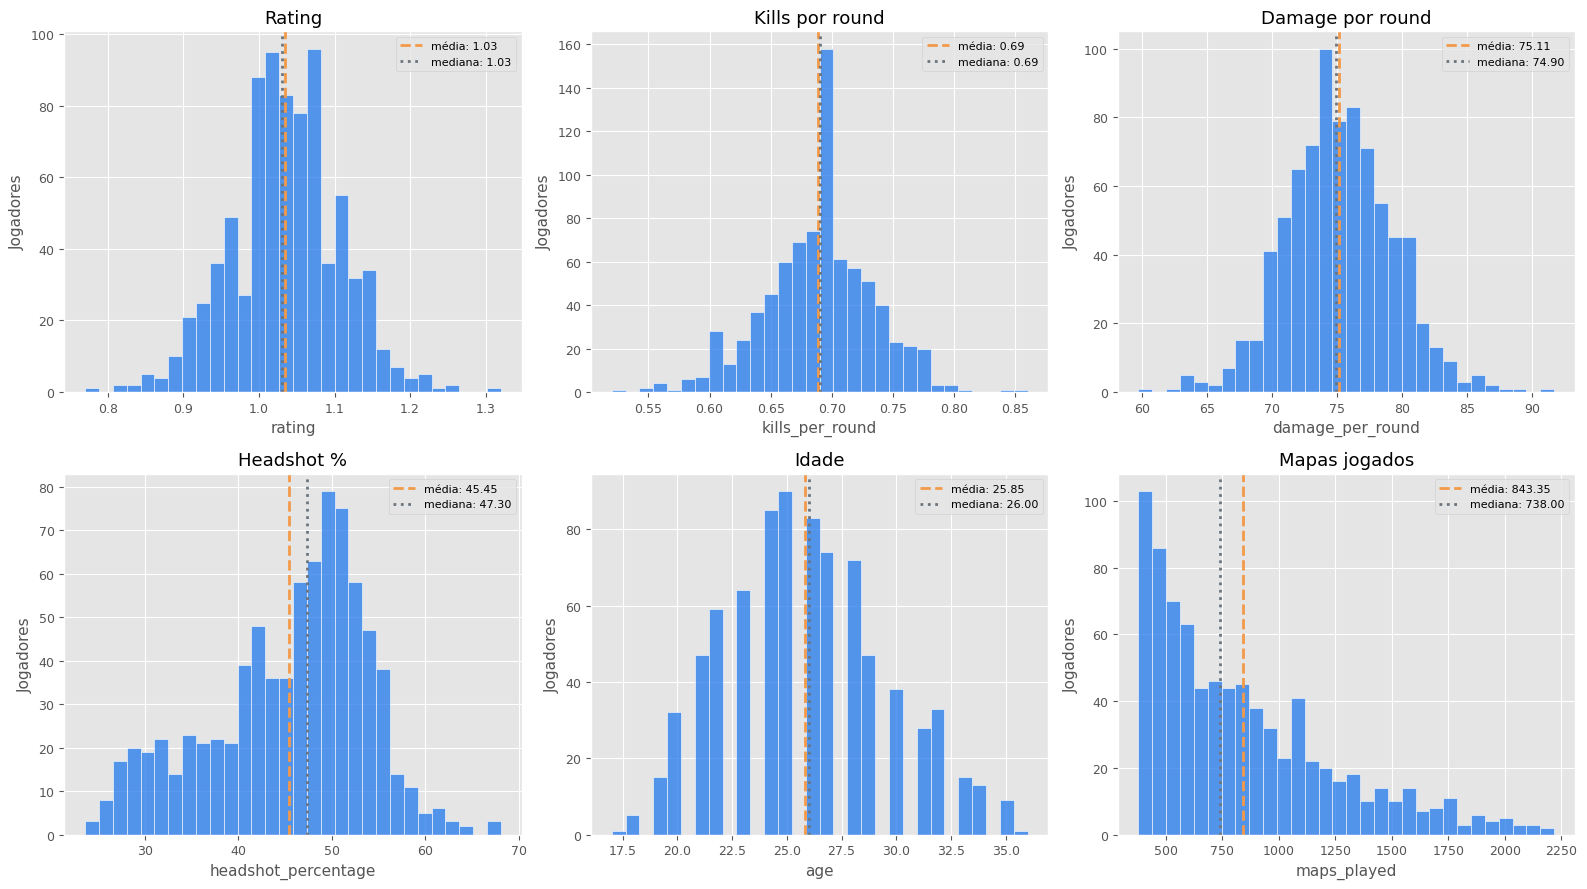

In [17]:
dist_cols = [
    ('rating', 'Rating'),
    ('kills_per_round', 'Kills por round'),
    ('damage_per_round', 'Damage por round'),
    ('headshot_percentage', 'Headshot %'),
    ('age', 'Idade'),
    ('maps_played', 'Mapas jogados')
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, dist_cols):
    ax.hist(df[col].dropna(), bins=30, color=rating_color, alpha=0.8, edgecolor='white')
    ax.axvline(df[col].mean(), color=highlight_color, linestyle='--', linewidth=2, label=f"média: {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color=neutral_color, linestyle=':', linewidth=2, label=f"mediana: {df[col].median():.2f}")
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Jogadores')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Relações com `rating`

Agora olhamos quais métricas parecem acompanhar melhor o `rating`. Os gráficos de dispersão ajudam a enxergar tendência, ruído e possíveis outliers.

In [ ]:
scatter_cols = [
    ('kills_per_round', 'Kills por round'),
    ('damage_per_round', 'Damage por round'),
    ('deaths_per_round', 'Deaths por round'),
    ('opening_kill_rating', 'Opening kill rating'),
    ('headshot_percentage', 'Headshot %'),
    ('maps_played', 'Mapas jogados')
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, scatter_cols):
    ax.scatter(df[col], df['rating'], alpha=0.65, s=28, color=rating_color, edgecolors='none')
    z = np.polyfit(df[col], df['rating'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), color=highlight_color, linewidth=2)
    ax.set_title(f'Rating vs. {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Rating')

plt.tight_layout()
plt.show()

## 10. Correlações

Mapa de correlação entre as principais métricas numéricas. Valores próximos de `1` indicam relação positiva forte; próximos de `-1`, relação negativa forte.

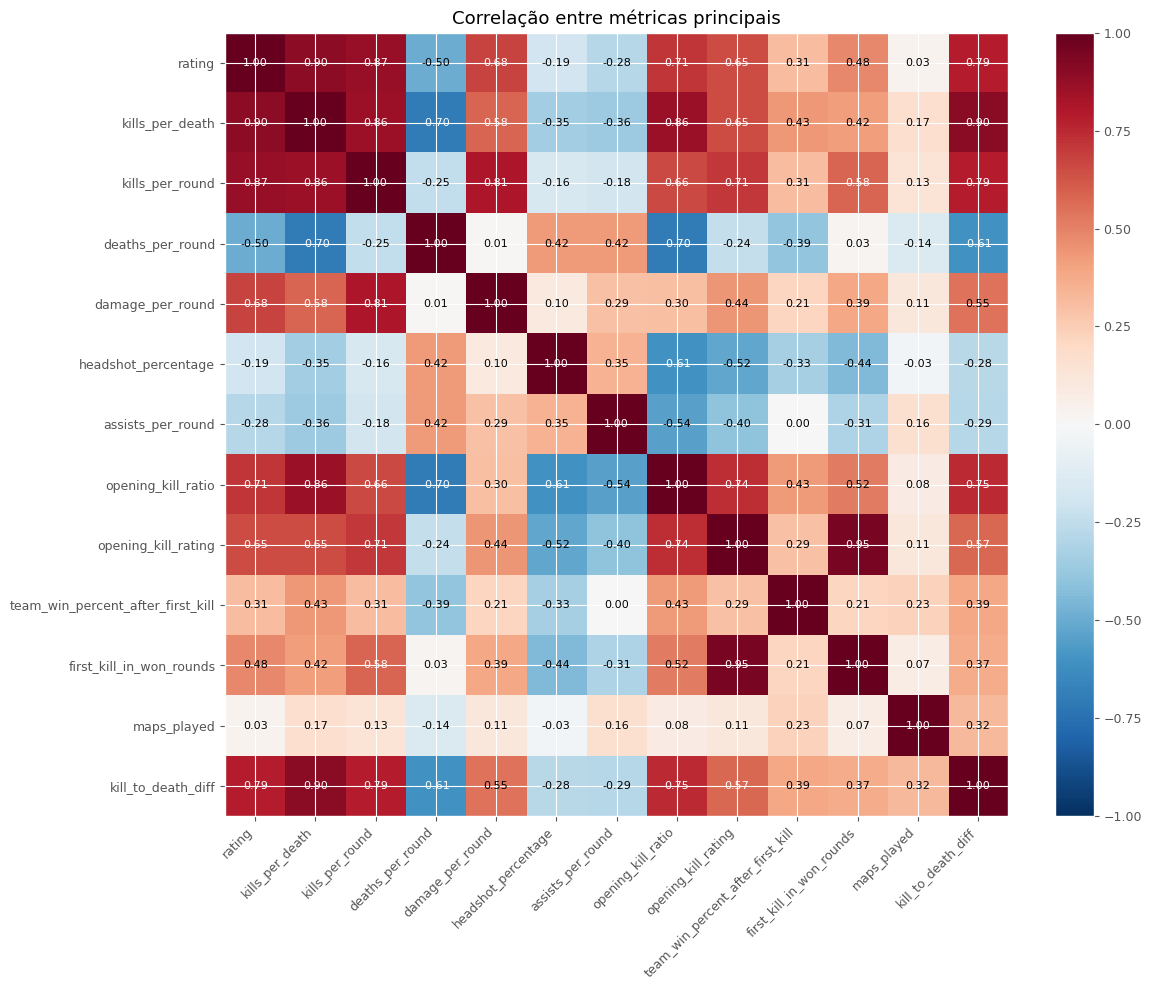

In [18]:
corr_cols = [
    'rating', 'kills_per_death', 'kills_per_round', 'deaths_per_round',
    'damage_per_round', 'headshot_percentage', 'assists_per_round',
    'opening_kill_ratio', 'opening_kill_rating', 'team_win_percent_after_first_kill',
    'first_kill_in_won_rounds', 'maps_played', 'kill_to_death_diff'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr.iloc[i, j]
        color = 'white' if abs(value) > 0.55 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=color, fontsize=8)

ax.set_title('Correlação entre métricas principais')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 11. Comparação por país

Para evitar distorção por amostras pequenas, usamos apenas países com pelo menos 10 jogadores no dataset.

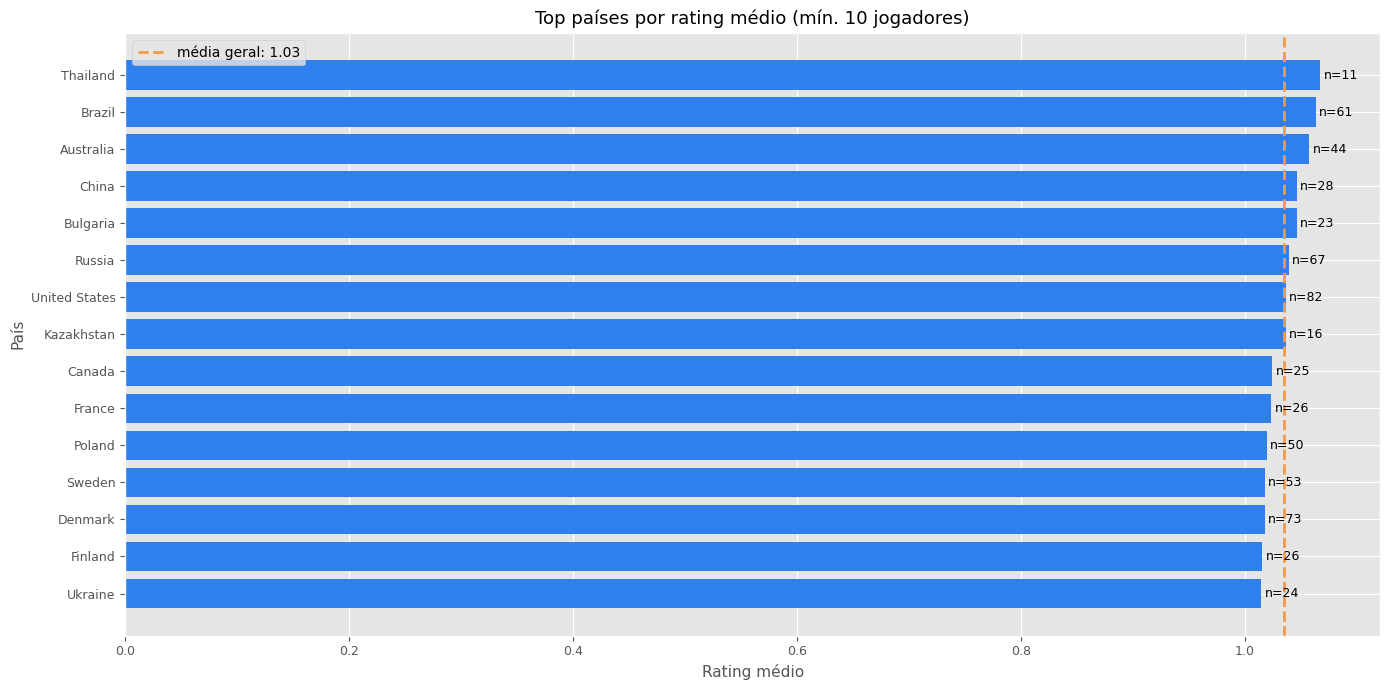

,players,avg_rating,avg_kpr,avg_hs
country,,,,
Thailand,11,1.067,0.702,44.018
Brazil,61,1.063,0.697,43.498
Australia,44,1.058,0.698,44.620
China,28,1.046,0.708,47.954
Bulgaria,23,1.046,0.687,45.609
Russia,67,1.039,0.683,45.454
United States,82,1.036,0.692,44.143
Kazakhstan,16,1.036,0.682,48.244
Canada,25,1.024,0.685,47.168


In [19]:
country_summary = (
    df.groupby('country')
      .agg(players=('player_id', 'count'), avg_rating=('rating', 'mean'), avg_kpr=('kills_per_round', 'mean'), avg_hs=('headshot_percentage', 'mean'))
      .query('players >= 10')
      .sort_values('avg_rating', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 7))
plot_data = country_summary.head(15).sort_values('avg_rating')
ax.barh(plot_data.index, plot_data['avg_rating'], color=rating_color)
ax.axvline(df['rating'].mean(), color=highlight_color, linestyle='--', linewidth=2, label=f"média geral: {df['rating'].mean():.2f}")

for i, (country, row) in enumerate(plot_data.iterrows()):
    ax.text(row['avg_rating'] + 0.003, i, f"n={int(row['players'])}", va='center', fontsize=9)

ax.set_title('Top países por rating médio (mín. 10 jogadores)')
ax.set_xlabel('Rating médio')
ax.set_ylabel('País')
ax.legend()
plt.tight_layout()
plt.show()

country_summary.head(15).round(3)

## 12. Comparação por time atual

Mesmo cuidado: mantemos apenas times atuais com pelo menos 5 jogadores no dataset.

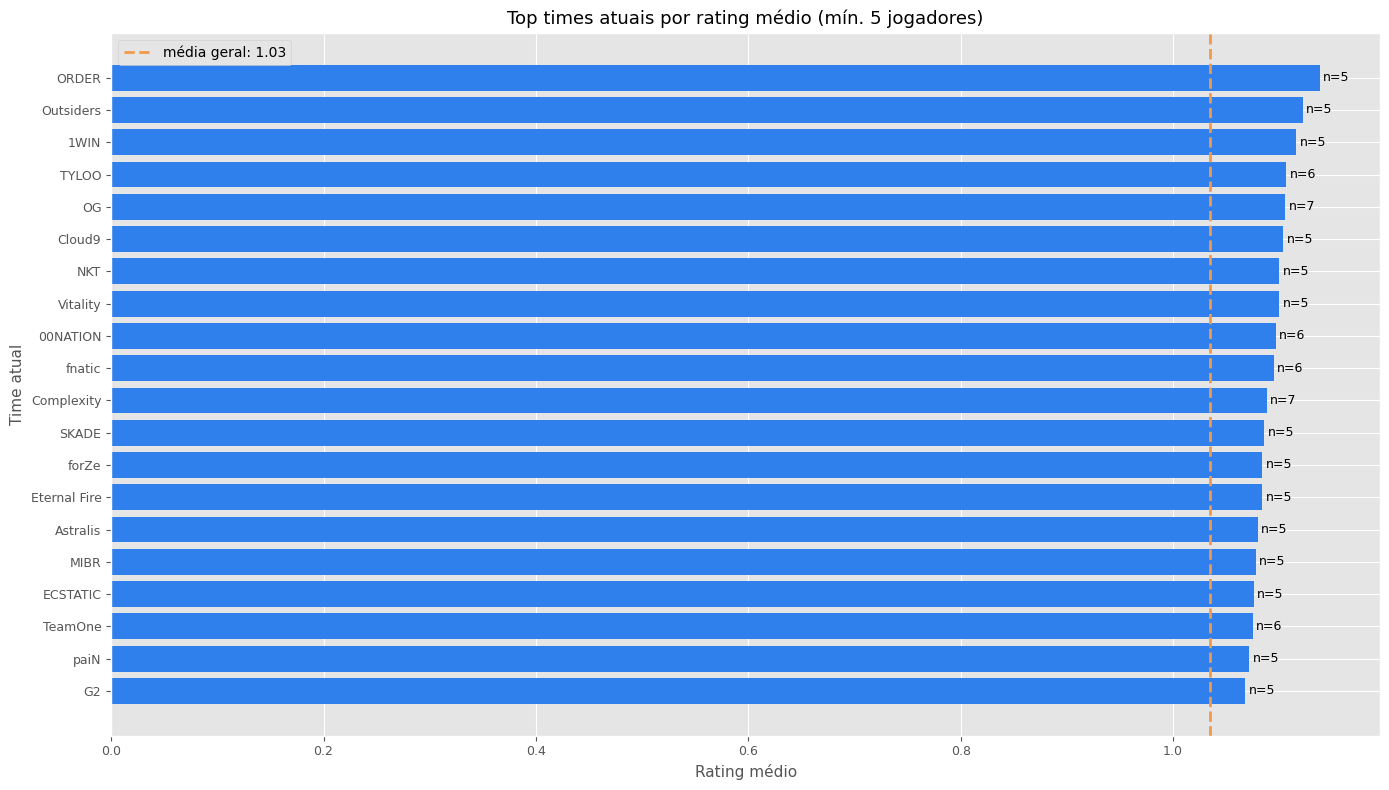

,players,avg_rating,avg_kpr,avg_maps
current_team,,,,
ORDER,5,1.138,0.732,966.000
Outsiders,5,1.122,0.720,1060.200
1WIN,5,1.116,0.734,842.800
TYLOO,6,1.107,0.738,934.000
OG,7,1.106,0.727,864.429
Cloud9,5,1.104,0.692,955.400
NKT,5,1.100,0.742,725.200
Vitality,5,1.100,0.726,1368.800
00NATION,6,1.097,0.722,830.667


In [20]:
team_summary = (
    df.dropna(subset=['current_team'])
      .groupby('current_team')
      .agg(players=('player_id', 'count'), avg_rating=('rating', 'mean'), avg_kpr=('kills_per_round', 'mean'), avg_maps=('maps_played', 'mean'))
      .query('players >= 5')
      .sort_values('avg_rating', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 8))
plot_data = team_summary.head(20).sort_values('avg_rating')
ax.barh(plot_data.index, plot_data['avg_rating'], color=rating_color)
ax.axvline(df['rating'].mean(), color=highlight_color, linestyle='--', linewidth=2, label=f"média geral: {df['rating'].mean():.2f}")

for i, (team, row) in enumerate(plot_data.iterrows()):
    ax.text(row['avg_rating'] + 0.003, i, f"n={int(row['players'])}", va='center', fontsize=9)

ax.set_title('Top times atuais por rating médio (mín. 5 jogadores)')
ax.set_xlabel('Rating médio')
ax.set_ylabel('Time atual')
ax.legend()
plt.tight_layout()
plt.show()

team_summary.head(20).round(3)

## 13. Perfil por arma

Criamos proporções de kills por arma para visualizar estilos. Ex.: AWPers tendem a ter `sniper_share` alto; riflers tendem a concentrar `rifle_share`.

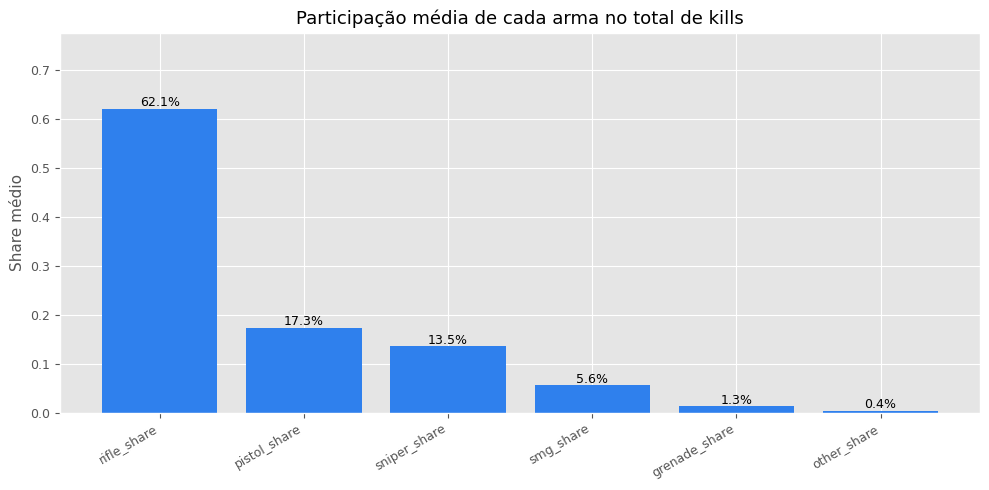

rifle_share      62.1%
pistol_share     17.3%
sniper_share     13.5%
smg_share         5.6%
grenade_share     1.3%
other_share       0.4%
dtype: str

In [21]:
weapon_cols = ['rifle_kills', 'sniper_kills', 'smg_kills', 'pistol_kills', 'grenade_kills', 'other_kills']
weapon_share_cols = []

for col in weapon_cols:
    share_col = col.replace('_kills', '_share')
    df[share_col] = df[col] / df['total_kills']
    weapon_share_cols.append(share_col)

weapon_share_summary = df[weapon_share_cols].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(weapon_share_summary.index, weapon_share_summary.values, color=rating_color)
ax.set_title('Participação média de cada arma no total de kills')
ax.set_ylabel('Share médio')
ax.set_ylim(0, weapon_share_summary.max() * 1.25)

for i, value in enumerate(weapon_share_summary.values):
    ax.text(i, value + 0.005, f'{value:.1%}', ha='center', fontsize=9)

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

weapon_share_summary.apply(lambda x: f'{x:.1%}')

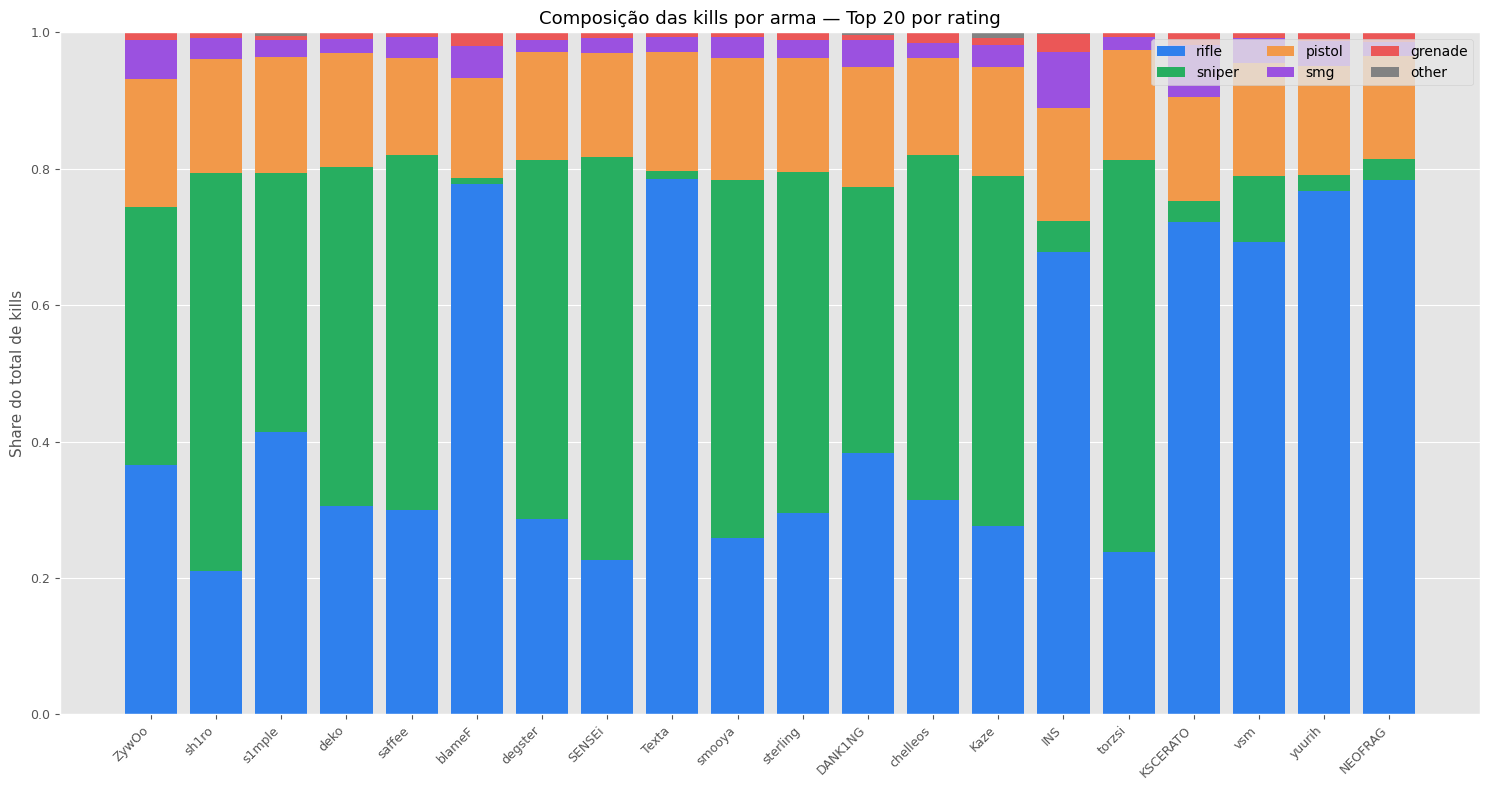

In [22]:
top_rating_players = df.nlargest(20, 'rating').copy()
stack_cols = ['rifle_share', 'sniper_share', 'pistol_share', 'smg_share', 'grenade_share', 'other_share']
colors = ['#2f80ed', '#27ae60', '#f2994a', '#9b51e0', '#eb5757', '#828282']

fig, ax = plt.subplots(figsize=(15, 8))
bottom = np.zeros(len(top_rating_players))

for col, color in zip(stack_cols, colors):
    values = top_rating_players[col].values
    ax.bar(top_rating_players['nickname'], values, bottom=bottom, label=col.replace('_share', ''), color=color)
    bottom += values

ax.set_title('Composição das kills por arma — Top 20 por rating')
ax.set_ylabel('Share do total de kills')
ax.set_ylim(0, 1)
ax.legend(ncol=3, loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 14. Outliers e rankings específicos

Aqui buscamos pontas interessantes: maior rating, maior headshot, maior impacto de abertura e maior concentração em AWP/rifle.

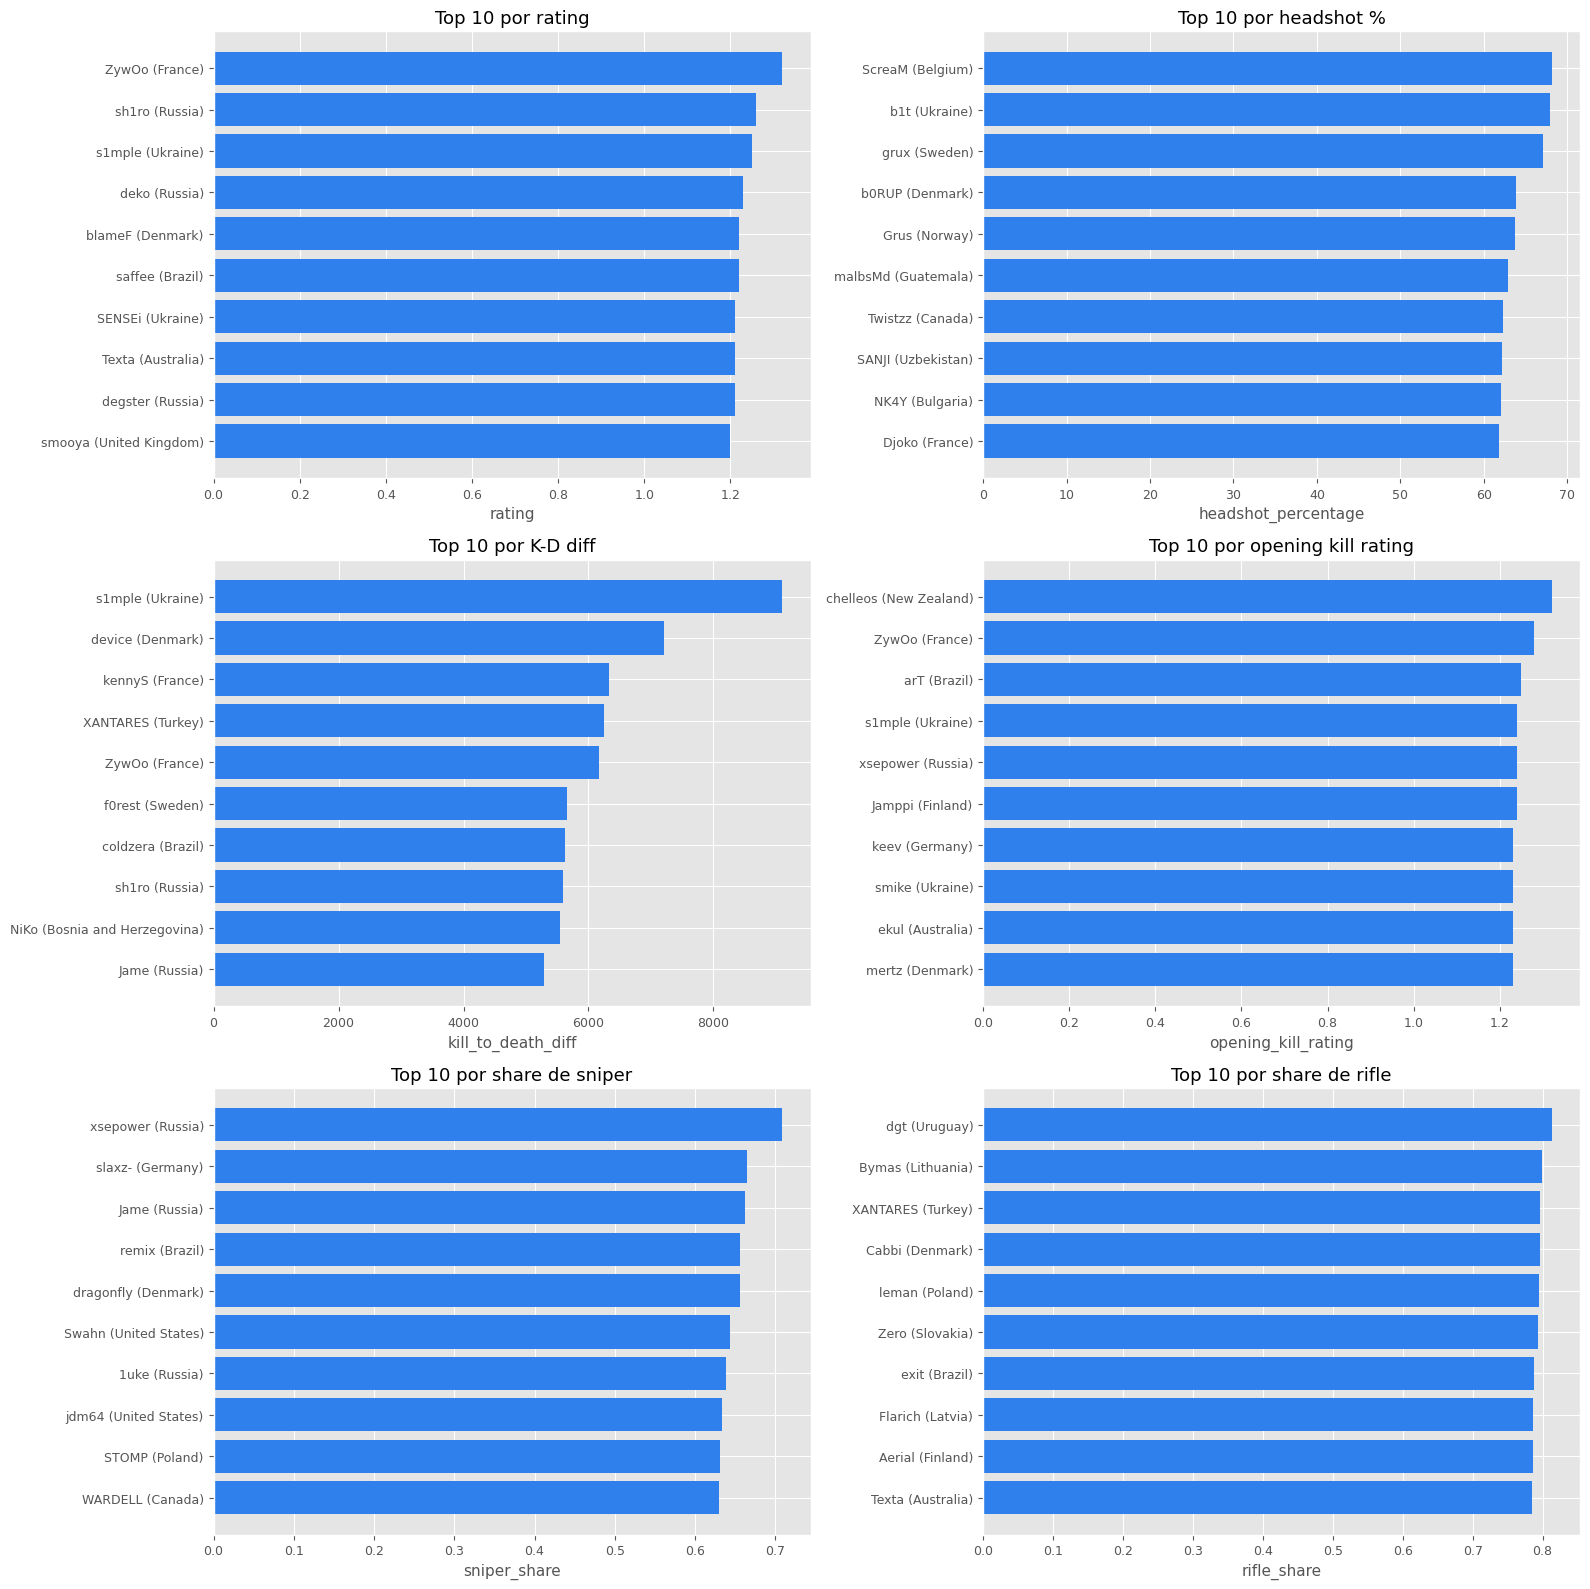

In [23]:
ranking_specs = [
    ('rating', 'Top 10 por rating'),
    ('headshot_percentage', 'Top 10 por headshot %'),
    ('kill_to_death_diff', 'Top 10 por K-D diff'),
    ('opening_kill_rating', 'Top 10 por opening kill rating'),
    ('sniper_share', 'Top 10 por share de sniper'),
    ('rifle_share', 'Top 10 por share de rifle')
]

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, ranking_specs):
    plot_data = df.nlargest(10, metric).sort_values(metric)
    labels = plot_data['nickname'] + ' (' + plot_data['country'] + ')'
    ax.barh(labels, plot_data[metric], color=rating_color)
    ax.set_title(title)
    ax.set_xlabel(metric)

plt.tight_layout()
plt.show()

## 15. Próximas hipóteses para investigar

A partir das visualizações acima, boas perguntas para aprofundar:

- Quais métricas explicam melhor `rating`?
- AWPers têm distribuição de rating diferente dos riflers?
- Existe relação entre idade e performance?
- Países com mais jogadores também têm melhores médias?
- Jogadores com muito mapa jogado são mais consistentes ou apenas mais expostos?

## 16. Idade vs. performance

Investigamos se idade influencia desempenho. Olhamos correlação, dispersão com `rating` e médias por faixa etária para várias métricas-chave.

In [ ]:
age_perf_cols = ['rating', 'kills_per_round', 'damage_per_round',
                 'headshot_percentage', 'opening_kill_rating', 'kills_per_death']

age_corr = df[['age'] + age_perf_cols].corr()['age'].drop('age').sort_values()

print('Correlação de Pearson entre idade e cada métrica:')
for metric, value in age_corr.items():
    print(f'  {metric:<25s} {value:+.3f}')

In [25]:
age_bins = [16, 20, 23, 26, 29, 40]
age_labels = ['<=20', '21-23', '24-26', '27-29', '30+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True)

age_group_summary = (
    df.groupby('age_group', observed=True)
      .agg(players=('player_id', 'count'),
           rating=('rating', 'mean'),
           kpr=('kills_per_round', 'mean'),
           dpr=('damage_per_round', 'mean'),
           hs=('headshot_percentage', 'mean'),
           opening=('opening_kill_rating', 'mean'),
           kd=('kills_per_death', 'mean'))
      .round(3)
)
age_group_summary

,players,rating,kpr,dpr,hs,opening,kd
age_group,,,,,,,
<=20,53,1.077,0.698,75.921,50.055,1.022,1.053
21-23,170,1.078,0.702,75.923,45.892,1.037,1.065
24-26,258,1.041,0.692,75.593,46.103,1.014,1.042
27-29,193,1.012,0.682,74.746,44.438,1.008,1.022
30+,137,0.984,0.669,73.395,43.339,0.999,0.999


C:\Users\rafaelg\AppData\Local\Temp\ipykernel_24456\4153890091.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=age_labels, patch_artist=True, showmeans=True,


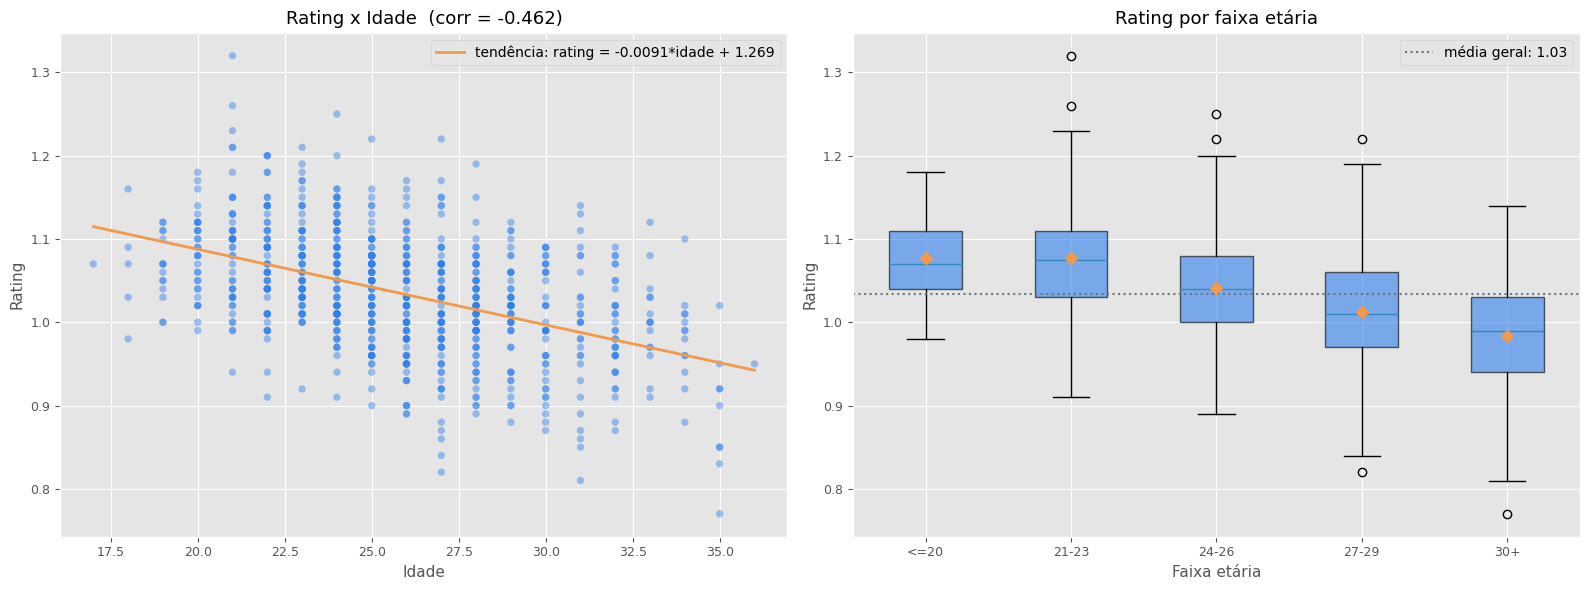

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.scatter(df['age'], df['rating'], alpha=0.45, s=28, color=rating_color, edgecolors='none')
z = np.polyfit(df['age'], df['rating'], 1)
p = np.poly1d(z)
xs = np.linspace(df['age'].min(), df['age'].max(), 100)
ax.plot(xs, p(xs), color=highlight_color, linewidth=2,
        label=f'tendência: rating = {z[0]:+.4f}*idade + {z[1]:.3f}')
ax.set_title(f"Rating x Idade  (corr = {df['age'].corr(df['rating']):+.3f})")
ax.set_xlabel('Idade')
ax.set_ylabel('Rating')
ax.legend()

ax = axes[1]
groups = [df.loc[df['age_group'] == g, 'rating'].dropna().values for g in age_labels]
bp = ax.boxplot(groups, labels=age_labels, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor=highlight_color, markeredgecolor=highlight_color))
for patch in bp['boxes']:
    patch.set_facecolor(rating_color)
    patch.set_alpha(0.6)
ax.set_title('Rating por faixa etária')
ax.set_xlabel('Faixa etária')
ax.set_ylabel('Rating')
ax.axhline(df['rating'].mean(), color=neutral_color, linestyle=':', linewidth=1.5,
           label=f"média geral: {df['rating'].mean():.2f}")
ax.legend()

plt.tight_layout()
plt.show()

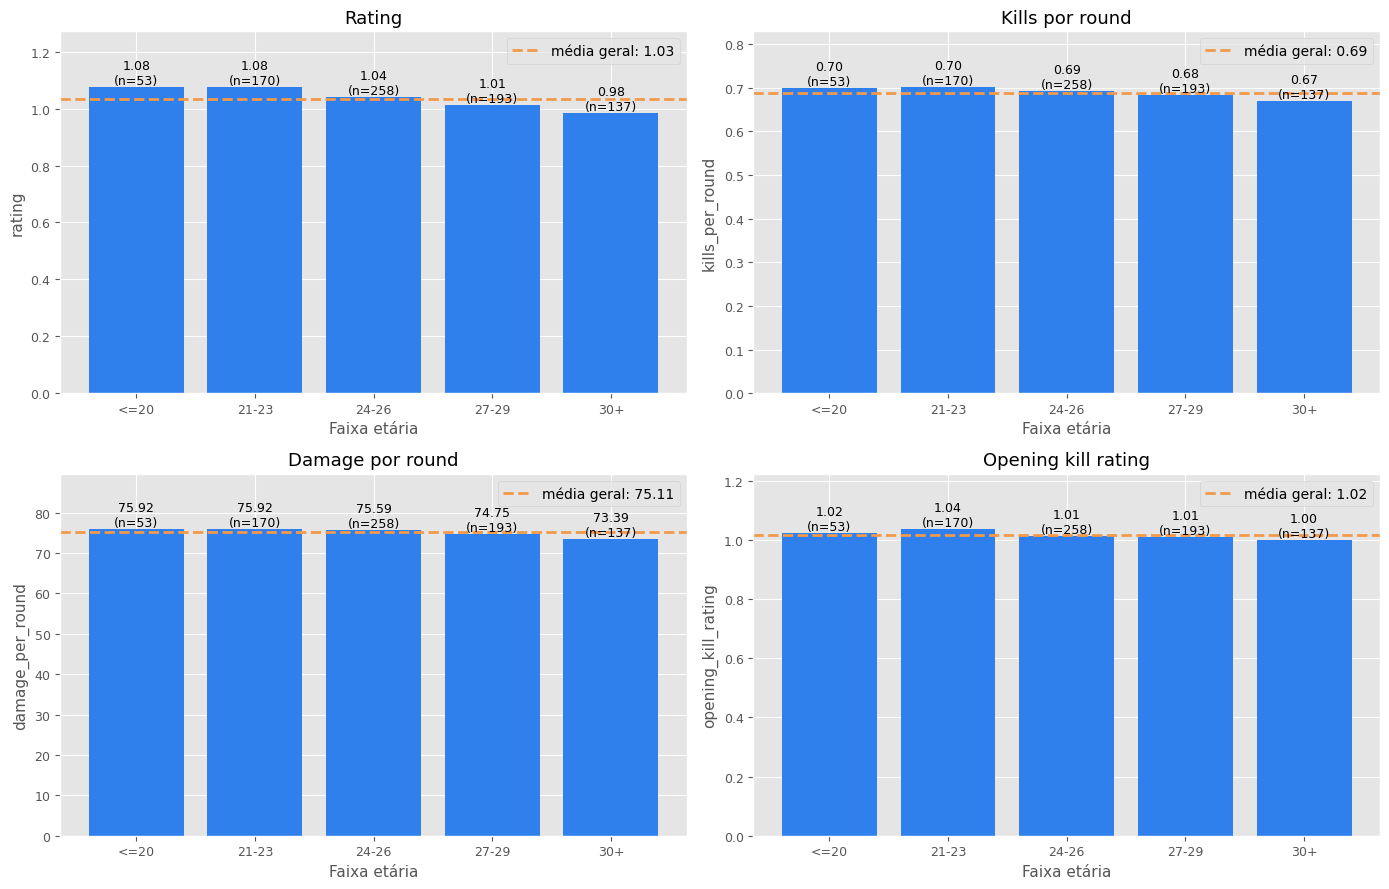

In [27]:
metric_panel = [
    ('rating', 'Rating'),
    ('kills_per_round', 'Kills por round'),
    ('damage_per_round', 'Damage por round'),
    ('opening_kill_rating', 'Opening kill rating')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
for ax, (col, title) in zip(axes, metric_panel):
    means = df.groupby('age_group', observed=True)[col].mean()
    counts = df.groupby('age_group', observed=True)[col].count()
    bars = ax.bar(means.index.astype(str), means.values, color=rating_color)
    overall = df[col].mean()
    ax.axhline(overall, color=highlight_color, linestyle='--', linewidth=2,
               label=f'média geral: {overall:.2f}')
    for bar, val, n in zip(bars, means.values, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val,
                f'{val:.2f}\n(n={n})', ha='center', va='bottom', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('Faixa etária')
    ax.set_ylabel(col)
    ax.set_ylim(0, means.max() * 1.18)
    ax.legend()

plt.tight_layout()
plt.show()

## 17. Desempenho do Brasil

Comparamos a cena brasileira contra a média global e contra os outros 4 países com maior representação no dataset (EUA, Dinamarca, Rússia, Suécia).

In [28]:
brazil_df = df[df['country'] == 'Brazil'].copy()

key_metrics = ['rating', 'kills_per_round', 'kills_per_death', 'damage_per_round',
               'headshot_percentage', 'opening_kill_rating', 'opening_kill_ratio',
               'assists_per_round', 'saved_teammates_per_round', 'maps_played']

compare = pd.DataFrame({
    'Brasil (média)': brazil_df[key_metrics].mean(),
    'Brasil (mediana)': brazil_df[key_metrics].median(),
    'Global (média)': df[key_metrics].mean(),
    'Diferença vs global': brazil_df[key_metrics].mean() - df[key_metrics].mean()
}).round(3)

print(f"Total de jogadores brasileiros: {len(brazil_df)}")
print(f"Times brasileiros únicos no dataset: {brazil_df['current_team'].nunique(dropna=True)}")
print(f"Idade média BR: {brazil_df['age'].mean():.1f} (global: {df['age'].mean():.1f})")
compare

Total de jogadores brasileiros: 61
Times brasileiros únicos no dataset: 12
Idade média BR: 25.9 (global: 25.9)


,Brasil (média),Brasil (mediana),Global (média),Diferença vs global
rating,1.063,1.07,1.034,0.029
kills_per_round,0.697,0.69,0.688,0.009
kills_per_death,1.069,1.06,1.035,0.034
damage_per_round,75.982,75.60,75.111,0.871
headshot_percentage,43.498,45.10,45.454,-1.956
opening_kill_rating,1.031,1.01,1.015,0.016
opening_kill_ratio,1.114,1.08,1.060,0.055
assists_per_round,0.131,0.13,0.131,0.001
saved_teammates_per_round,0.095,0.09,0.097,-0.001
maps_played,779.639,732.00,843.348,-63.708


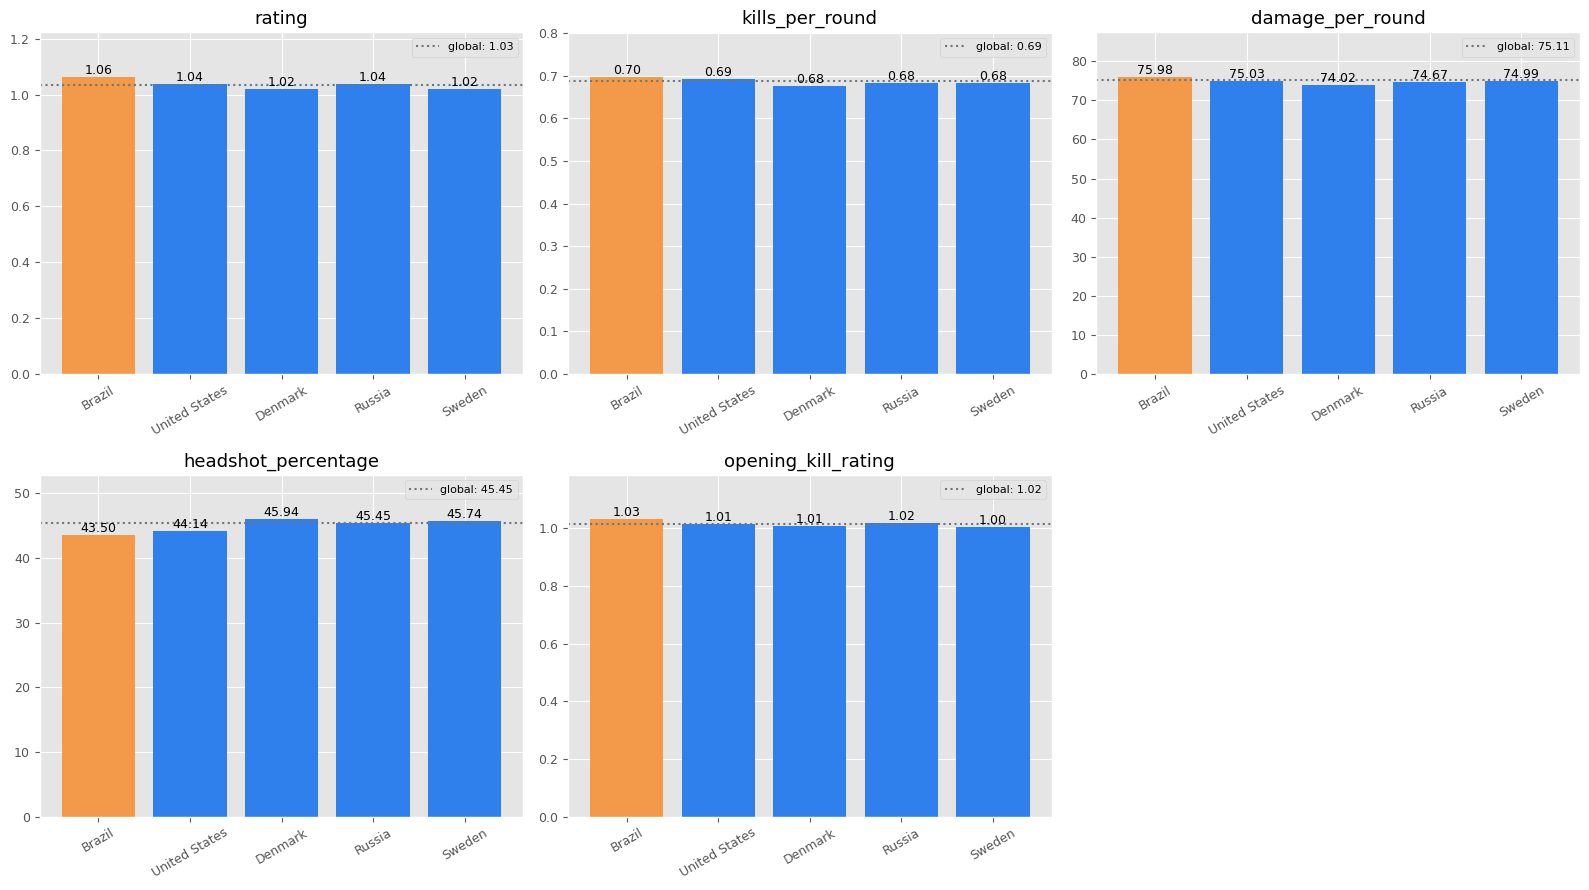

,rating,kills_per_round,damage_per_round,headshot_percentage,opening_kill_rating
country,,,,,
Brazil,1.063,0.697,75.982,43.498,1.031
United States,1.036,0.692,75.026,44.143,1.014
Denmark,1.018,0.676,74.015,45.942,1.009
Russia,1.039,0.683,74.673,45.454,1.017
Sweden,1.018,0.683,74.992,45.745,1.005


In [30]:
focus_countries = ['Brazil', 'United States', 'Denmark', 'Russia', 'Sweden']
focus_metrics = ['rating', 'kills_per_round', 'damage_per_round',
                 'headshot_percentage', 'opening_kill_rating']

country_compare = (
    df[df['country'].isin(focus_countries)]
      .groupby('country')[focus_metrics]
      .mean()
      .reindex(focus_countries)
      .round(3)
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, metric in zip(axes, focus_metrics):
    values = country_compare[metric]
    colors = [highlight_color if c == 'Brazil' else rating_color for c in values.index]
    bars = ax.bar(values.index, values.values, color=colors)
    overall = df[metric].mean()
    ax.axhline(overall, color=neutral_color, linestyle=':', linewidth=1.5,
               label=f'global: {overall:.2f}')
    for bar, val in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric)
    ax.set_ylim(0, values.max() * 1.15)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

country_compare

In [31]:
top_br = brazil_df.nlargest(10, 'rating')[
    ['nickname', 'real_name', 'age', 'current_team', 'rating',
     'kills_per_round', 'damage_per_round', 'headshot_percentage',
     'opening_kill_rating', 'maps_played']
].reset_index(drop=True)

print('Top 10 brasileiros por rating:')
top_br

Top 10 brasileiros por rating:


,nickname,real_name,age,current_team,rating,kills_per_round,damage_per_round,headshot_percentage,opening_kill_rating,maps_played
0,saffee,Rafael Costa,27,FURIA,1.22,0.79,80.2,30.9,1.14,404
1,KSCERATO,Kaike Cerato,22,FURIA,1.18,0.74,79.2,49.4,0.99,930
2,vsm,Vinicius Moreira,23,00NATION,1.18,0.77,83.6,47.0,1.12,533
3,yuurih,Yuri Santos,22,FURIA,1.18,0.76,84.2,44.3,1.03,1022
4,dumau,Eduardo Wolkmer,18,00NATION,1.16,0.74,80.2,41.6,1.07,473
5,biguzera,Rodrigo Bittencourt,25,paiN,1.16,0.73,80.6,51.2,1.03,622
6,coldzera,Marcelo David,27,00NATION,1.15,0.77,79.2,49.4,1.01,1426
7,JOTA,Jhonatan Willian,24,MIBR,1.15,0.73,82.2,41.6,1.04,430
8,nython,Gabriel Lino,24,paiN,1.14,0.75,76.7,37.6,1.15,524
9,trk,Alencar Rossato,27,TeamOne,1.14,0.73,79.4,48.2,1.01,830


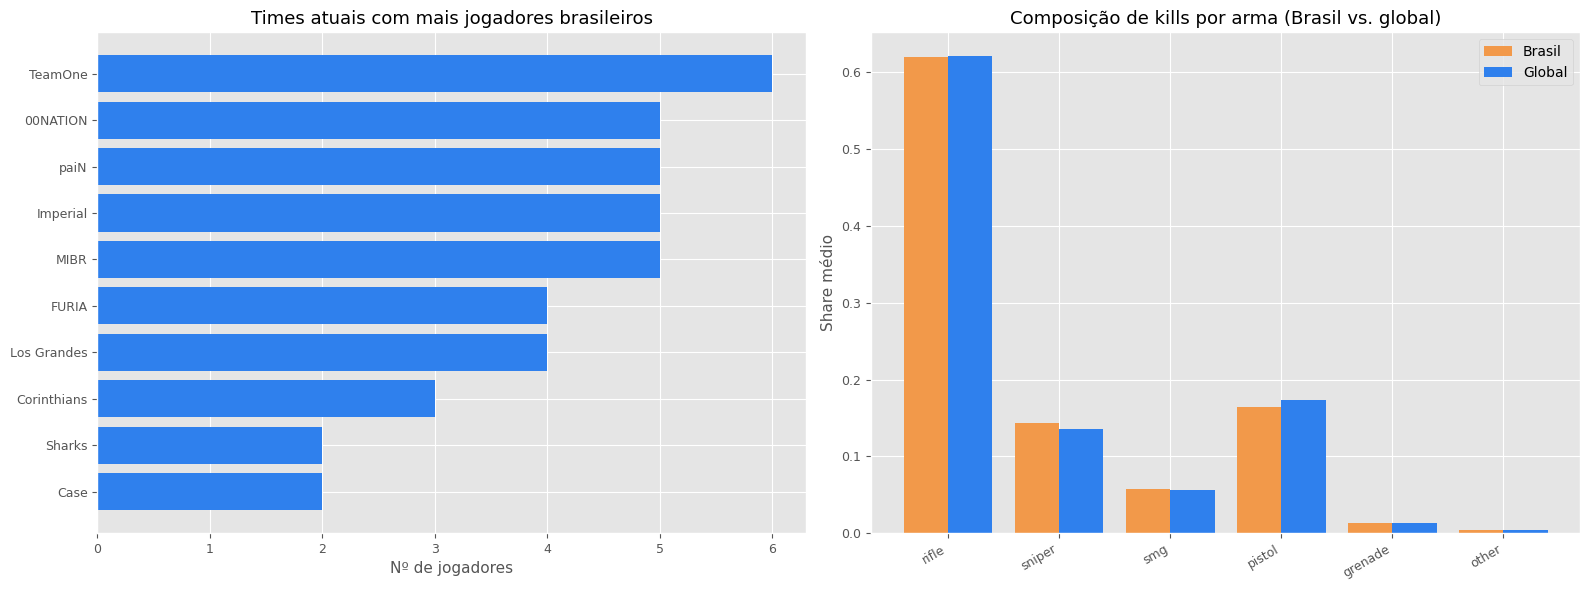

In [32]:
br_team_counts = brazil_df.dropna(subset=['current_team'])['current_team'].value_counts().head(10)
br_weapon_share = brazil_df[weapon_share_cols].mean()
global_weapon_share = df[weapon_share_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.barh(br_team_counts.index[::-1], br_team_counts.values[::-1], color=rating_color)
ax.set_title('Times atuais com mais jogadores brasileiros')
ax.set_xlabel('Nº de jogadores')

ax = axes[1]
x = np.arange(len(weapon_share_cols))
width = 0.4
ax.bar(x - width/2, br_weapon_share.values, width, color=highlight_color, label='Brasil')
ax.bar(x + width/2, global_weapon_share.values, width, color=rating_color, label='Global')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_share', '') for c in weapon_share_cols], rotation=30, ha='right')
ax.set_title('Composição de kills por arma (Brasil vs. global)')
ax.set_ylabel('Share médio')
ax.legend()

plt.tight_layout()
plt.show()

## 18. Top 5 times e seus principais jogadores

Ranqueamos times pelo `rating` médio (mínimo 5 jogadores) e, dentro de cada um, identificamos o melhor jogador e a métrica em que ele mais se destaca em relação ao time.

In [33]:
team_ranking = (
    df.dropna(subset=['current_team'])
      .groupby('current_team')
      .agg(players=('player_id', 'count'),
           avg_rating=('rating', 'mean'),
           best_player_rating=('rating', 'max'),
           avg_kpr=('kills_per_round', 'mean'),
           avg_hs=('headshot_percentage', 'mean'),
           avg_dpr=('damage_per_round', 'mean'))
      .query('players >= 5')
      .sort_values('avg_rating', ascending=False)
      .round(3)
)

top5_teams = team_ranking.head(5)
top5_team_names = top5_teams.index.tolist()
print('Top 5 times por rating médio (mínimo 5 jogadores):')
top5_teams

Top 5 times por rating médio (mínimo 5 jogadores):


,players,avg_rating,best_player_rating,avg_kpr,avg_hs,avg_dpr
current_team,,,,,,
ORDER,5,1.138,1.19,0.732,41.960,79.300
Outsiders,5,1.122,1.17,0.720,47.380,77.660
1WIN,5,1.116,1.23,0.734,50.040,79.240
TYLOO,6,1.107,1.20,0.738,47.283,78.950
OG,7,1.106,1.21,0.727,48.371,79.229


In [34]:
highlight_metrics = ['rating', 'kills_per_round', 'damage_per_round',
                     'headshot_percentage', 'opening_kill_rating', 'kills_per_death']

global_means = df[highlight_metrics].mean()
global_stds = df[highlight_metrics].std()

records = []
for team in top5_team_names:
    team_df = df[df['current_team'] == team]
    best = team_df.loc[team_df['rating'].idxmax()]
    z_scores = (best[highlight_metrics] - global_means) / global_stds
    top_metric = z_scores.idxmax()
    records.append({
        'team': team,
        'avg_rating': round(team_df['rating'].mean(), 3),
        'best_player': best['nickname'],
        'country': best['country'],
        'rating': best['rating'],
        'kills_per_round': best['kills_per_round'],
        'damage_per_round': best['damage_per_round'],
        'headshot_percentage': best['headshot_percentage'],
        'opening_kill_rating': best['opening_kill_rating'],
        'best_metric_vs_global': top_metric,
        'best_metric_value': round(best[top_metric], 3),
        'best_metric_zscore': round(z_scores[top_metric], 2)
    })

top5_best_players = pd.DataFrame(records)
top5_best_players

,team,avg_rating,best_player,country,rating,kills_per_round,damage_per_round,headshot_percentage,opening_kill_rating,best_metric_vs_global,best_metric_value,best_metric_zscore
0,ORDER,1.138,INS,Australia,1.19,0.76,85.6,42.5,1.08,damage_per_round,85.60,2.55
1,Outsiders,1.122,Jame,Russia,1.17,0.72,73.0,25.2,1.15,kills_per_death,1.31,3.00
2,1WIN,1.116,deko,Russia,1.23,0.80,80.4,36.7,1.13,kills_per_death,1.37,3.65
3,TYLOO,1.107,DANK1NG,China,1.20,0.79,79.8,39.7,1.19,rating,1.20,2.28
4,OG,1.106,degster,Russia,1.21,0.78,79.3,34.7,1.21,kills_per_death,1.31,3.00


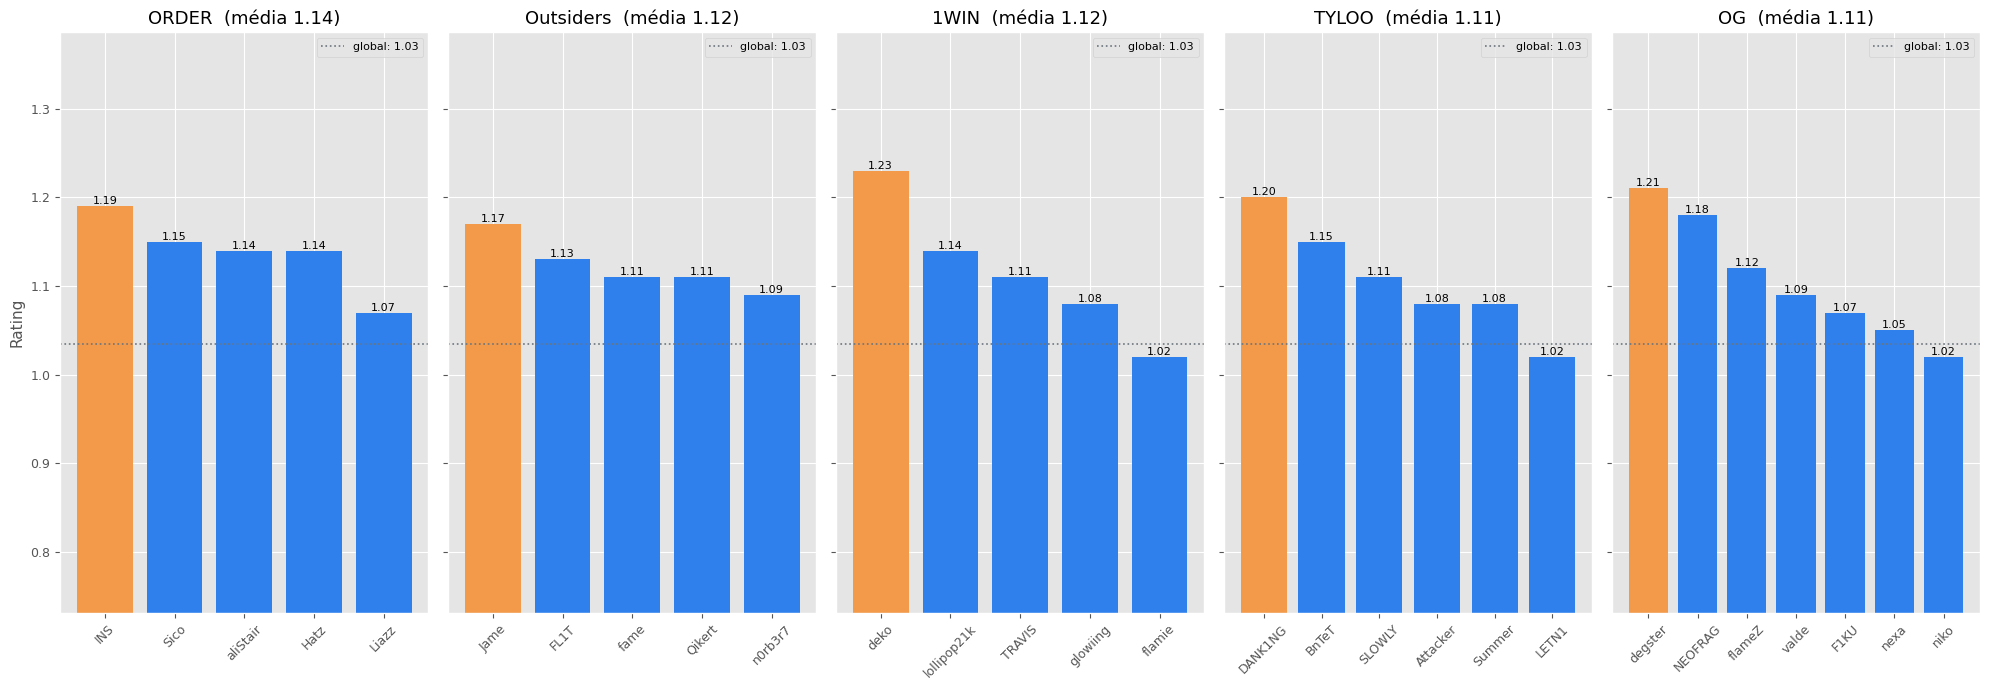

In [35]:
fig, axes = plt.subplots(1, 5, figsize=(20, 7), sharey=True)

for ax, team in zip(axes, top5_team_names):
    team_df = df[df['current_team'] == team].sort_values('rating', ascending=False).reset_index(drop=True)
    colors = [highlight_color if i == 0 else rating_color for i in range(len(team_df))]
    bars = ax.bar(team_df['nickname'], team_df['rating'], color=colors)
    ax.axhline(df['rating'].mean(), color=neutral_color, linestyle=':', linewidth=1.2,
               label=f"global: {df['rating'].mean():.2f}")
    for bar, val in zip(bars, team_df['rating']):
        ax.text(bar.get_x() + bar.get_width() / 2, val,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f"{team}  (média {team_df['rating'].mean():.2f})")
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(df['rating'].min() * 0.95, df['rating'].max() * 1.05)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Rating')
plt.tight_layout()
plt.show()

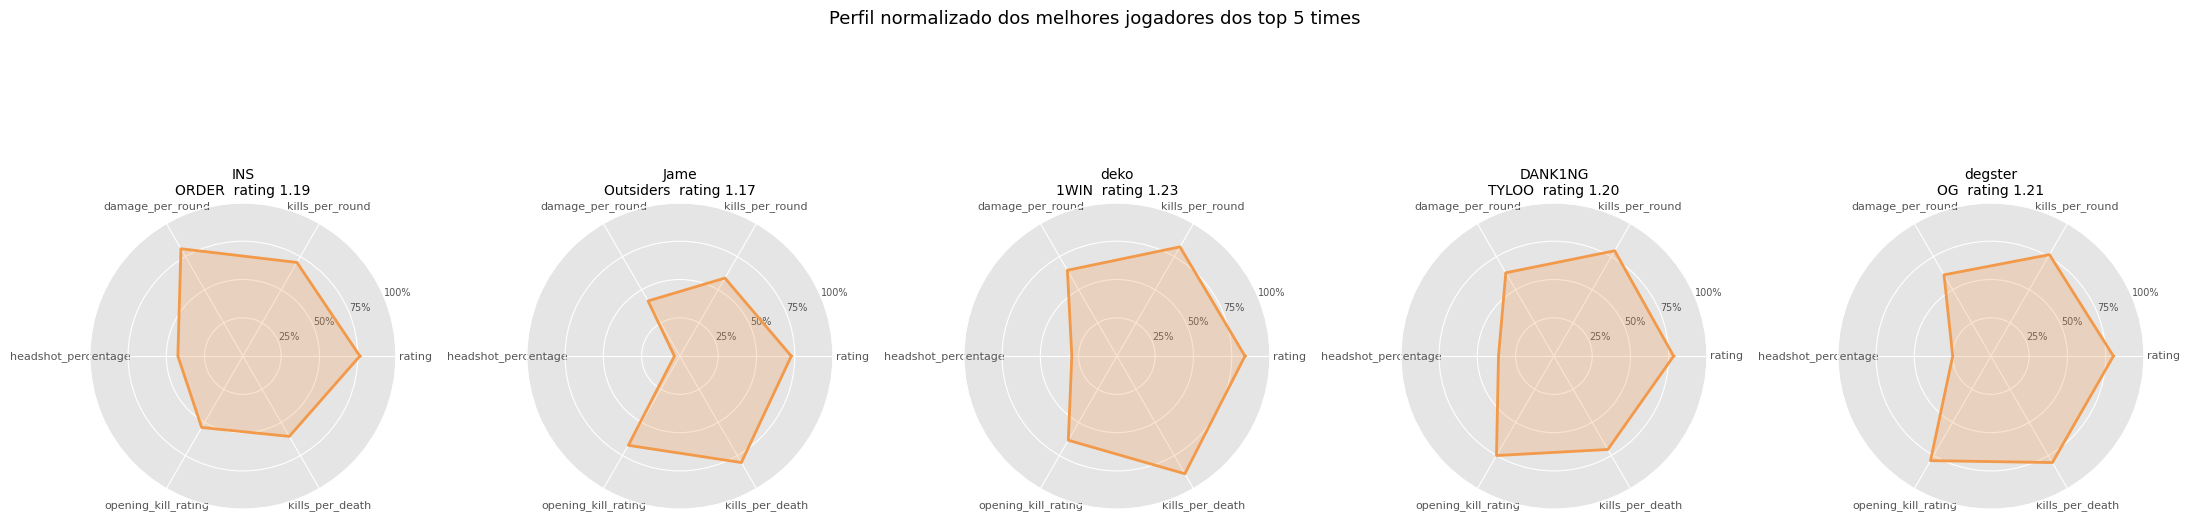

In [36]:
radar_metrics = ['rating', 'kills_per_round', 'damage_per_round',
                 'headshot_percentage', 'opening_kill_rating', 'kills_per_death']

mins = df[radar_metrics].min()
maxs = df[radar_metrics].max()

def normalize(row):
    return (row[radar_metrics] - mins) / (maxs - mins)

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 5, figsize=(22, 6), subplot_kw=dict(polar=True))

for ax, (_, row) in zip(axes, top5_best_players.iterrows()):
    player_row = df[(df['nickname'] == row['best_player']) & (df['current_team'] == row['team'])].iloc[0]
    values = normalize(player_row).tolist()
    values += values[:1]
    ax.plot(angles, values, color=highlight_color, linewidth=2)
    ax.fill(angles, values, color=highlight_color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=8)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title(f"{row['best_player']}\n{row['team']}  rating {row['rating']:.2f}", fontsize=10)

plt.suptitle('Perfil normalizado dos melhores jogadores dos top 5 times', y=1.05, fontsize=13)
plt.tight_layout()
plt.show()